Part 2.3 - Creative AI: Generating Broccoli Sketches with a DCGAN (QuickDraw)


In [ ]:
!pip install -q torchmetrics torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 89.9 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cu

In [ ]:
import os, math, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision.utils import make_grid

SEED = 7
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Z_DIM   = 100
IMG_CH  = 1
CACHE   = "/content/quickdraw"
os.makedirs(CACHE, exist_ok=True)

# --- consistent, clean plot styling for every figure in this notebook ---
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 11, "legend.fontsize": 9, "legend.framealpha": 0.9,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
})


Device: cuda


1. Download and explore the broccoli category

downloading broccoli ...
broccoli bitmaps: (132826, 784)


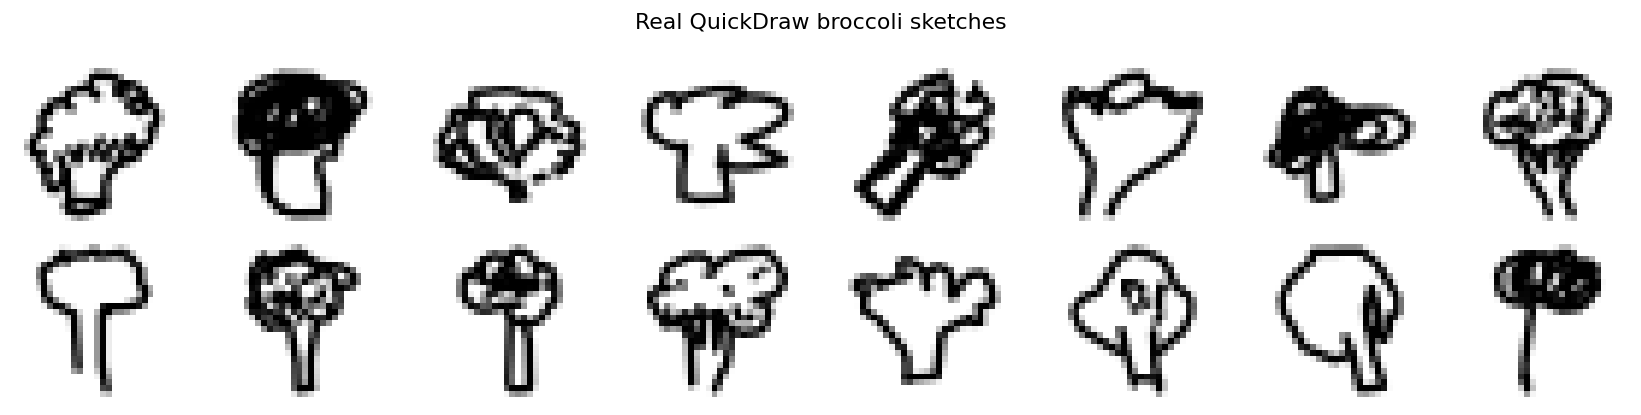

In [ ]:
QUICKDRAW_URL = ("https://storage.googleapis.com/quickdraw_dataset/"
                 "full/numpy_bitmap/{}.npy")

def download_category(name):
    """Fetch one QuickDraw category bitmap file, caching it under CACHE."""
    dest = os.path.join(CACHE, name.replace(" ", "_") + ".npy")
    if not os.path.exists(dest):
        print("downloading", name, "...")
        urllib.request.urlretrieve(QUICKDRAW_URL.format(name.replace(" ", "%20")), dest)
    return np.load(dest)

def to_image_tensor(bitmaps, n_keep=40000):
    """Pick n_keep bitmaps and scale uint8 [0,255] -> float [-1, 1], shape (N,1,28,28)."""
    idx = np.random.choice(len(bitmaps), min(n_keep, len(bitmaps)), replace=False)
    imgs = bitmaps[idx].reshape(-1, 1, 28, 28).astype(np.float32) / 127.5 - 1.0
    return torch.tensor(imgs)

broccoli_raw = download_category("broccoli")
print("broccoli bitmaps:", broccoli_raw.shape)

sel = np.random.choice(len(broccoli_raw), 16, replace=False)
fig, axes = plt.subplots(2, 8, figsize=(14, 3.5))
for ax, i in zip(axes.ravel(), sel):
    ax.imshow(broccoli_raw[i].reshape(28, 28), cmap="gray_r"); ax.axis("off")
plt.suptitle("Real QuickDraw broccoli sketches"); plt.tight_layout(); plt.show()

2. DCGAN architecture


In [ ]:
def dcgan_init(layer):
    """DCGAN weight initialisation (Radford et al., 2015)."""
    k = type(layer)
    if k in (nn.Conv2d, nn.ConvTranspose2d, nn.Linear):
        nn.init.normal_(layer.weight, 0.0, 0.02)
        if layer.bias is not None: nn.init.zeros_(layer.bias)
    elif k == nn.BatchNorm2d:
        nn.init.normal_(layer.weight, 1.0, 0.02); nn.init.zeros_(layer.bias)


class SketchGenerator(nn.Module):
    """z(100) -> 256x7x7 -> 128x14x14 -> 64x28x28 -> 1x28x28 (tanh)."""
    def __init__(self, z_dim=Z_DIM, base=256):
        super().__init__()
        self.base = base
        self.project = nn.Linear(z_dim, base * 7 * 7)
        self.decode = nn.Sequential(
            nn.BatchNorm2d(base), nn.ReLU(True),
            nn.ConvTranspose2d(base, base // 2, 4, 2, 1),     # 7 -> 14
            nn.BatchNorm2d(base // 2), nn.ReLU(True),
            nn.ConvTranspose2d(base // 2, base // 4, 4, 2, 1), # 14 -> 28
            nn.BatchNorm2d(base // 4), nn.ReLU(True),
            nn.Conv2d(base // 4, IMG_CH, 3, 1, 1), nn.Tanh())

    def forward(self, z):
        return self.decode(self.project(z).view(-1, self.base, 7, 7))


class SketchDiscriminator(nn.Module):
    """1x28x28 -> 64x14x14 -> 128x7x7 -> scalar probability."""
    def __init__(self, base=64, drop=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(IMG_CH, base, 4, 2, 1), nn.LeakyReLU(0.2, True),
            nn.Dropout2d(drop),
            nn.Conv2d(base, base * 2, 4, 2, 1), nn.BatchNorm2d(base * 2),
            nn.LeakyReLU(0.2, True), nn.Dropout2d(drop))
        self.classify = nn.Sequential(
            nn.Flatten(), nn.Linear(base * 2 * 7 * 7, 1), nn.Sigmoid())

    def forward(self, x):
        return self.classify(self.features(x))

3. Training routine


In [ ]:
@torch.no_grad()
def batch_diversity(gen, z_dim, n=64):
    """Mean pairwise L2 distance across a batch of generated images (collapse detector)."""
    gen.eval()
    imgs = gen(torch.randn(n, z_dim, device=DEVICE)).view(n, -1)
    d = torch.cdist(imgs, imgs)
    gen.train()
    return d.triu(1).sum().item() / (n * (n - 1) / 2)


def train_sketch_gan(data, epochs=30, batch=128, z_dim=Z_DIM,
                     g_lr=2e-4, real_label=0.9, snap_every=5):
    """Train the sketch DCGAN; tracks G/D loss, a diversity score, and periodic sample snapshots."""
    G = SketchGenerator().apply(dcgan_init).to(DEVICE)
    D = SketchDiscriminator().apply(dcgan_init).to(DEVICE)
    bce = nn.BCELoss()
    opt_g = torch.optim.Adam(G.parameters(), lr=g_lr,       betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(D.parameters(), lr=g_lr * 0.5, betas=(0.5, 0.999))  # TTUR
    loader = DataLoader(TensorDataset(data), batch_size=batch,
                        shuffle=True, drop_last=True, num_workers=2)
    fixed_z = torch.randn(16, z_dim, device=DEVICE)

    hist = {"d": [], "g": [], "div": [], "snap": {}}
    for ep in range(1, epochs + 1):
        d_run = g_run = steps = 0
        G.train(); D.train()
        for (real,) in loader:
            real = real.to(DEVICE); bs = real.size(0)
            real_y = torch.full((bs, 1), real_label, device=DEVICE)
            fake_y = torch.zeros((bs, 1), device=DEVICE)

            D.zero_grad()
            fake = G(torch.randn(bs, z_dim, device=DEVICE)).detach()
            d_loss = bce(D(real), real_y) + bce(D(fake), fake_y)
            d_loss.backward(); opt_d.step()

            G.zero_grad()
            g_loss = bce(D(G(torch.randn(bs, z_dim, device=DEVICE))), real_y)
            g_loss.backward(); opt_g.step()
            d_run += d_loss.item(); g_run += g_loss.item(); steps += 1

        hist["d"].append(d_run / steps); hist["g"].append(g_run / steps)
        hist["div"].append(batch_diversity(G, z_dim))
        if ep % snap_every == 0 or ep == epochs:
            G.eval()
            with torch.no_grad(): hist["snap"][ep] = G(fixed_z).cpu()
            print(f"epoch {ep:3d} | D {hist['d'][-1]:.3f} | G {hist['g'][-1]:.3f} "
                  f"| diversity {hist['div'][-1]:.2f}")
    return G, hist

In [ ]:
broccoli = to_image_tensor(broccoli_raw)
torch.manual_seed(SEED)
G, hist = train_sketch_gan(broccoli, epochs=30)

epoch   5 | D 1.294 | G 0.957 | diversity 24.13
epoch  10 | D 1.287 | G 0.955 | diversity 24.82
epoch  15 | D 1.290 | G 0.949 | diversity 24.39
epoch  20 | D 1.297 | G 0.944 | diversity 24.24
epoch  25 | D 1.295 | G 0.938 | diversity 24.17
epoch  30 | D 1.291 | G 0.938 | diversity 24.42


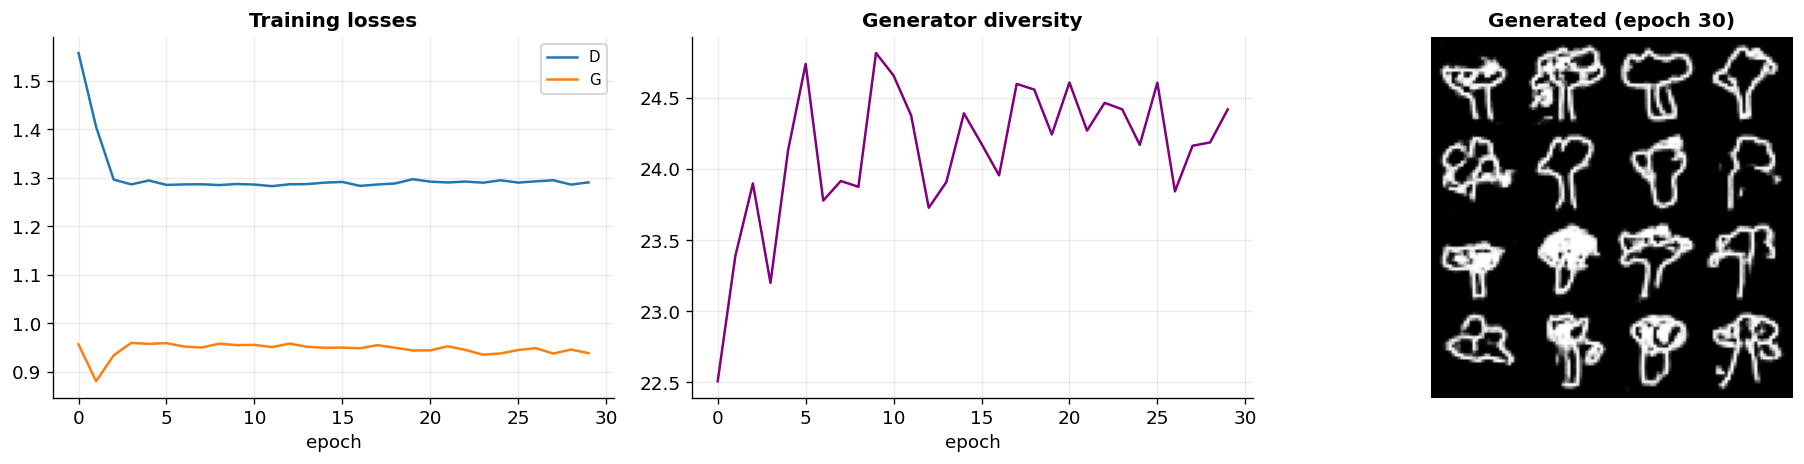

In [ ]:
# Loss + diversity curves, and the final generated grid.
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(hist["d"], label="D"); ax[0].plot(hist["g"], label="G")
ax[0].set_title("Training losses"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(hist["div"], color="purple"); ax[1].set_title("Generator diversity")
ax[1].set_xlabel("epoch")
last = max(hist["snap"])
grid = make_grid(hist["snap"][last], nrow=4, normalize=True, value_range=(-1, 1))
ax[2].imshow(grid.permute(1, 2, 0).numpy()[:, :, 0], cmap="gray")
ax[2].axis("off"); ax[2].set_title(f"Generated (epoch {last})")
plt.tight_layout(); plt.show()

4. Sample evolution across epochs


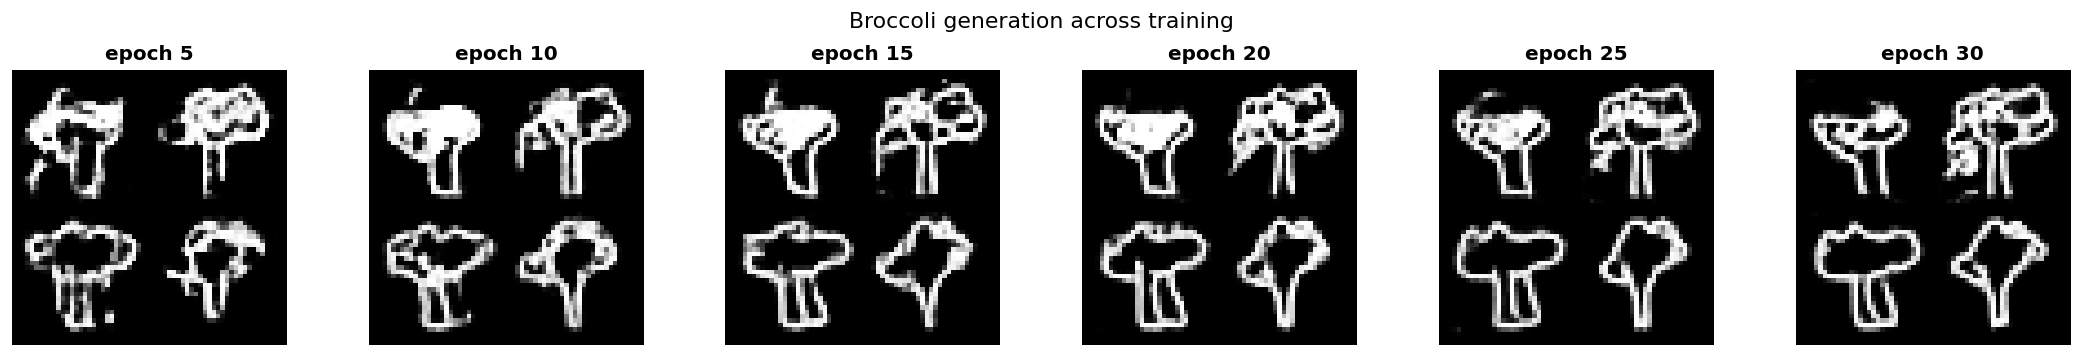

In [ ]:
snaps = sorted(hist["snap"])
show = snaps[:: max(1, len(snaps) // 5)][:5] + [snaps[-1]]
show = sorted(set(show))
fig, axes = plt.subplots(1, len(show), figsize=(3 * len(show), 3))
for ax, ep in zip(axes, show):
    g = make_grid(hist["snap"][ep][:4], nrow=2, normalize=True, value_range=(-1, 1))
    ax.imshow(g.permute(1, 2, 0).numpy()[:, :, 0], cmap="gray")
    ax.axis("off"); ax.set_title(f"epoch {ep}")
plt.suptitle("Broccoli generation across training"); plt.tight_layout(); plt.show()

5. Real vs. generated and FID

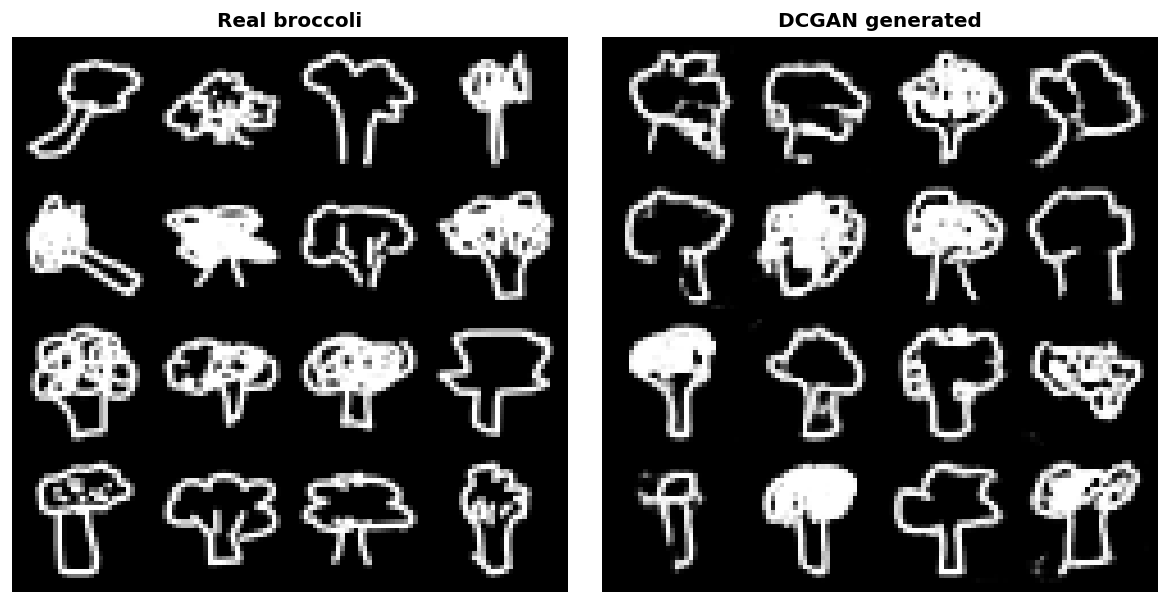

In [ ]:
G.eval()
with torch.no_grad():
    fake_sample = G(torch.randn(16, Z_DIM, device=DEVICE)).cpu()
real_sample = broccoli[np.random.choice(len(broccoli), 16, replace=False)]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
for a, imgs, t in zip(ax, [real_sample, fake_sample], ["Real broccoli", "DCGAN generated"]):
    g = make_grid(imgs, nrow=4, normalize=True, value_range=(-1, 1))
    a.imshow(g.permute(1, 2, 0).numpy()[:, :, 0], cmap="gray"); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

In [ ]:
@torch.no_grad()
def sketch_fid(gen, data, n_samples=2000, z_dim=Z_DIM):
    """FID between real sketches and generated ones (grayscale replicated to RGB)."""
    from torchmetrics.image.fid import FrechetInceptionDistance
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(DEVICE)

    def prep(batch):
        b = ((batch + 1) / 2).clamp(0, 1).repeat(1, 3, 1, 1)
        return F.interpolate(b, size=(299, 299), mode="bilinear", align_corners=False)

    idx = np.random.choice(len(data), min(n_samples, len(data)), replace=False)
    for s in range(0, len(idx), 100):
        fid.update(prep(data[idx[s:s + 100]].to(DEVICE)), real=True)

    gen.eval(); made = 0
    while made < n_samples:
        bs = min(100, n_samples - made)
        fid.update(prep(gen(torch.randn(bs, z_dim, device=DEVICE))), real=False)
        made += bs
    return float(fid.compute())

fid_broccoli = sketch_fid(G, broccoli)
print(f"Broccoli DCGAN FID: {fid_broccoli:.2f}  (lower is better)")

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 288MB/s]


Broccoli DCGAN FID: 14.01  (lower is better)


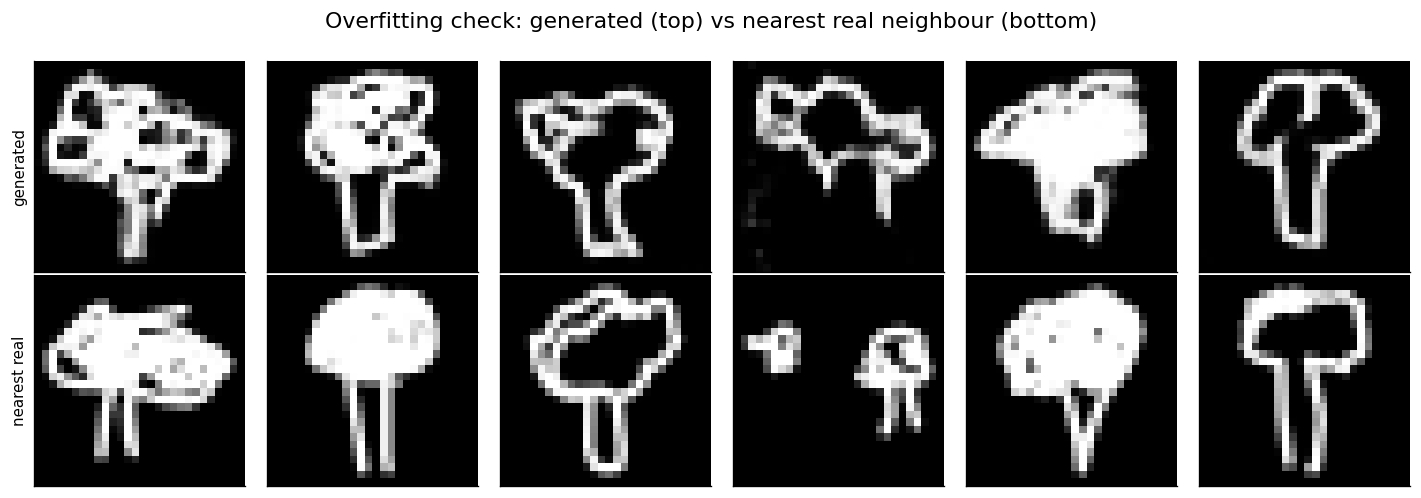

In [ ]:
# Overfitting check — nearest-neighbour test (Unit 5 lecture: "Checking overfitting").
# Each generated broccoli sketch is matched to its closest REAL sketch by L2 distance.
# Distinct neighbours confirm the generator is drawing novel sketches, not copying.
@torch.no_grad()
def nearest_neighbour_check(gen, real_pool, n_show=6, z_dim=Z_DIM):
    """Show generated sketches beside their closest real sketch (memorisation check)."""
    gen.eval()
    fake = gen(torch.randn(n_show, z_dim, device=DEVICE)).cpu()
    real_flat = real_pool.view(len(real_pool), -1)
    fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 4.2))
    for j in range(n_show):
        dist = (real_flat - fake[j].view(1, -1)).pow(2).sum(1)
        neigh = real_pool[int(dist.argmin())]
        axes[0, j].imshow(((fake[j, 0] + 1) / 2).clamp(0, 1).numpy(), cmap="gray")
        axes[1, j].imshow(((neigh[0] + 1) / 2).clamp(0, 1).numpy(), cmap="gray")
    for ax in axes.ravel():
        ax.set_xticks([]); ax.set_yticks([])
    axes[0, 0].set_ylabel("generated", fontsize=9)
    axes[1, 0].set_ylabel("nearest real", fontsize=9)
    plt.suptitle("Overfitting check: generated (top) vs nearest real neighbour (bottom)")
    plt.tight_layout(); plt.show()

real_pool = broccoli[np.random.choice(len(broccoli), 2000, replace=False)]
nearest_neighbour_check(G, real_pool)

In [ ]:
# --- Sketch-specific quantitative comparison: stroke sharpness + ink density ---
def sobel_sharpness(imgs):
    """Mean Sobel gradient magnitude — a proxy for how crisp the strokes are."""
    kx = torch.tensor([[-1., 0, 1], [-2, 0, 2], [-1, 0, 1]], device=DEVICE).view(1, 1, 3, 3)
    ky = kx.transpose(2, 3)
    g = imgs.to(DEVICE)
    edge = (F.conv2d(g, kx, padding=1) ** 2 + F.conv2d(g, ky, padding=1) ** 2).sqrt()
    return edge.mean().item()

def ink_density(imgs, thresh=0.0):
    """Fraction of 'ink' pixels (value below threshold in the [-1, 1] image space)."""
    return (imgs < thresh).float().mean().item()

G.eval()
with torch.no_grad():
    fake = G(torch.randn(256, Z_DIM, device=DEVICE)).cpu()
real = broccoli[np.random.choice(len(broccoli), 256, replace=False)]
print(f"Sharpness (Sobel) — real {sobel_sharpness(real):.3f} | generated {sobel_sharpness(fake):.3f}")
print(f"Ink density       — real {ink_density(real):.3f} | generated {ink_density(fake):.3f}")

Sharpness (Sobel) — real 2.721 | generated 2.756
Ink density       — real 0.788 | generated 0.772


6. Latent-space interpolation

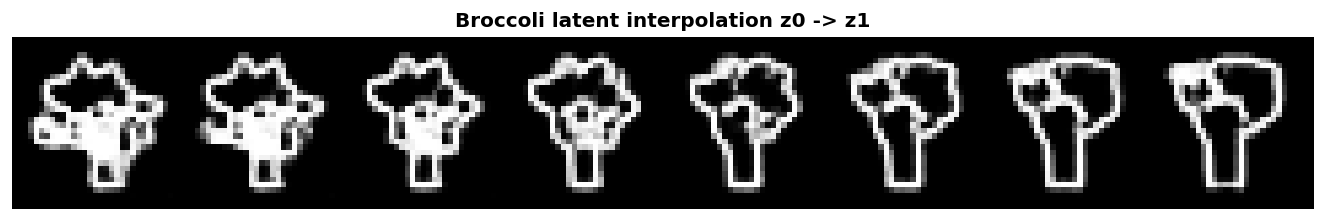

In [ ]:
@torch.no_grad()
def latent_walk(gen, steps=8, z_dim=Z_DIM):
    """Decode a straight-line path between two latent codes to check the manifold is smooth."""
    torch.manual_seed(0)
    z0, z1 = torch.randn(1, z_dim, device=DEVICE), torch.randn(1, z_dim, device=DEVICE)
    gen.eval()
    frames = [gen(z0 * (1 - a) + z1 * a).squeeze(0).cpu()
              for a in torch.linspace(0, 1, steps, device=DEVICE)]
    grid = make_grid(torch.stack(frames), nrow=steps, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(14, 2))
    plt.imshow(grid.permute(1, 2, 0).numpy()[:, :, 0], cmap="gray")
    plt.axis("off"); plt.title("Broccoli latent interpolation z0 -> z1"); plt.show()

latent_walk(G)

7. Extension - other categories and sketch complexity


=== training: cat ===
downloading cat ...


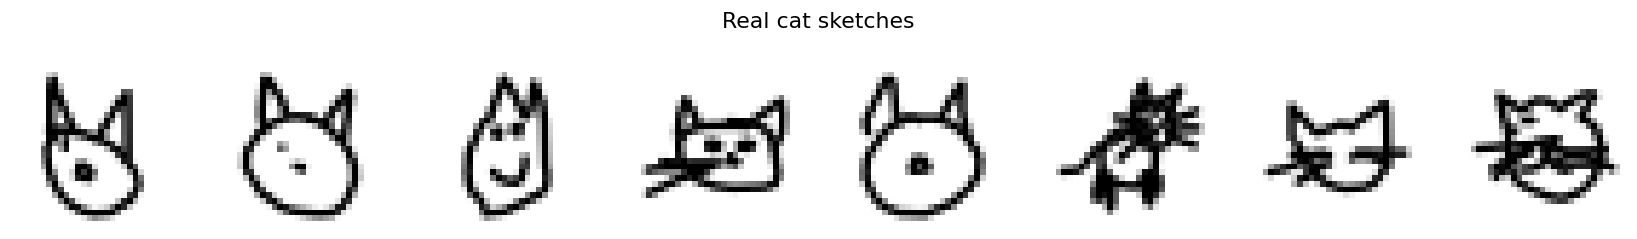

epoch   5 | D 1.255 | G 1.005 | diversity 23.18
epoch  10 | D 1.252 | G 1.015 | diversity 24.48
epoch  15 | D 1.204 | G 1.071 | diversity 23.98
epoch  20 | D 1.204 | G 1.083 | diversity 24.20
epoch  25 | D 1.203 | G 1.098 | diversity 24.41
epoch  30 | D 1.207 | G 1.082 | diversity 25.11


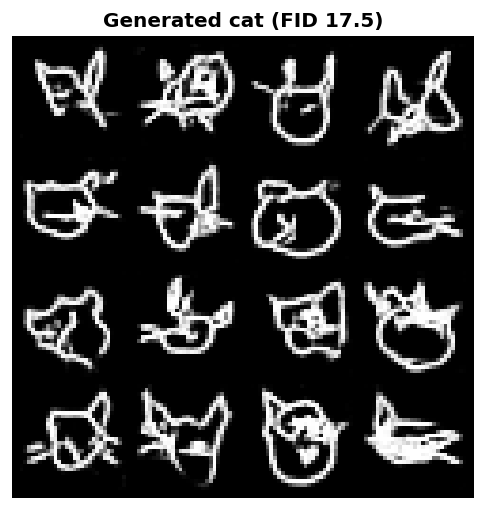


=== training: house ===
downloading house ...


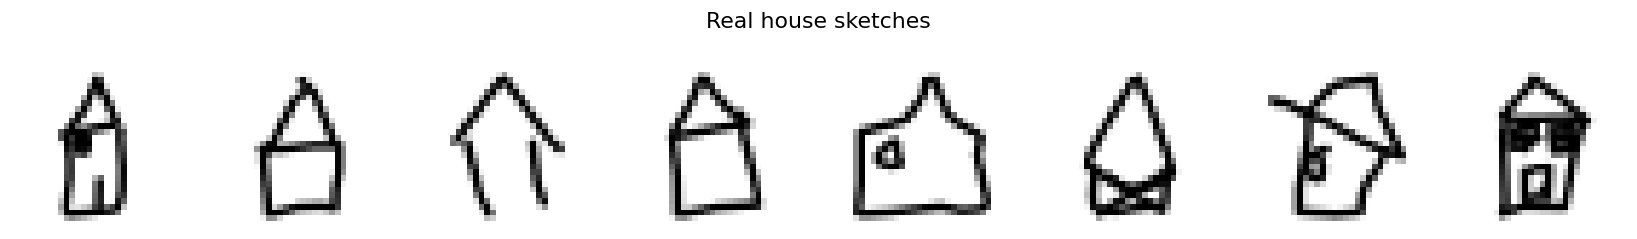

epoch   5 | D 1.121 | G 1.190 | diversity 22.49
epoch  10 | D 1.159 | G 1.142 | diversity 23.27
epoch  15 | D 1.218 | G 1.075 | diversity 22.46
epoch  20 | D 1.255 | G 1.029 | diversity 22.64
epoch  25 | D 1.260 | G 1.008 | diversity 21.75
epoch  30 | D 1.271 | G 0.982 | diversity 22.97


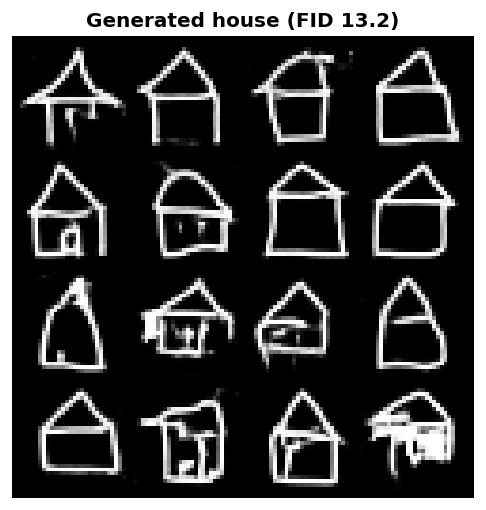

In [ ]:
EXTRA = ["cat", "house"]
results = {"broccoli": {"fid": fid_broccoli, "div": hist["div"][-1]}}

for name in EXTRA:
    print("\n=== training:", name, "===")
    torch.manual_seed(SEED); np.random.seed(SEED)
    raw = download_category(name)
    data = to_image_tensor(raw)

    sel = np.random.choice(len(raw), 8, replace=False)
    fig, axes = plt.subplots(1, 8, figsize=(14, 2))
    for ax, i in zip(axes, sel):
        ax.imshow(raw[i].reshape(28, 28), cmap="gray_r"); ax.axis("off")
    plt.suptitle(f"Real {name} sketches"); plt.tight_layout(); plt.show()

    Gx, hx = train_sketch_gan(data, epochs=30)
    fx = sketch_fid(Gx, data)
    results[name] = {"fid": fx, "div": hx["div"][-1]}

    grid = make_grid(hx["snap"][max(hx["snap"])], nrow=4, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(5, 5))
    plt.imshow(grid.permute(1, 2, 0).numpy()[:, :, 0], cmap="gray")
    plt.axis("off"); plt.title(f"Generated {name} (FID {fx:.1f})"); plt.show()

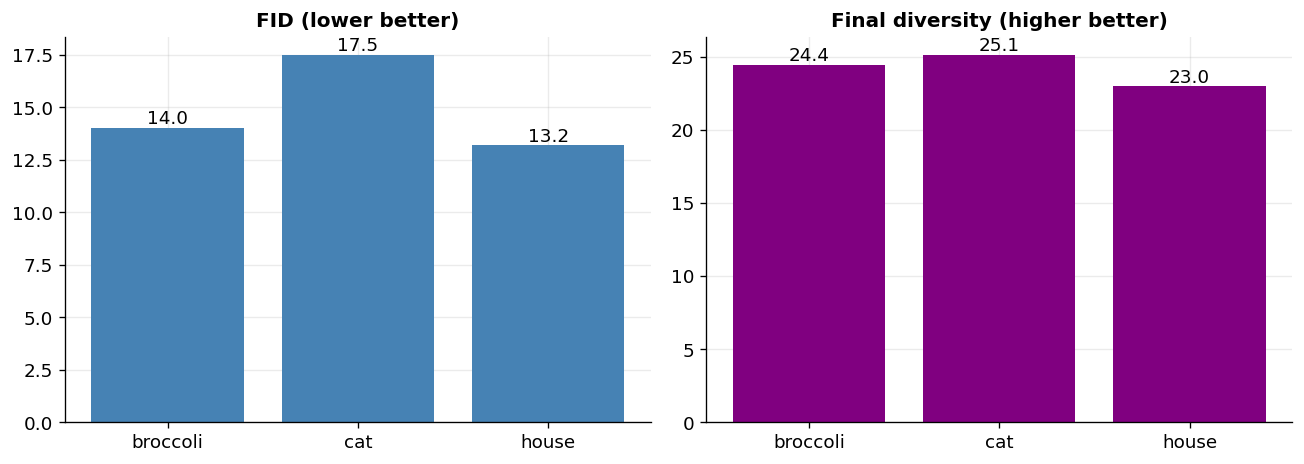

category       FID  diversity
broccoli     14.01      24.42
cat          17.49      25.11
house        13.20      22.97


In [ ]:
# Cross-category summary.
cats = list(results.keys())
fids = [results[c]["fid"] for c in cats]
divs = [results[c]["div"] for c in cats]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, vals, title, col in zip(ax, [fids, divs],
                               ["FID (lower better)", "Final diversity (higher better)"],
                               ["steelblue", "purple"]):
    bars = a.bar(cats, vals, color=col); a.set_title(title)
    for b, v in zip(bars, vals):
        a.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{v:.1f}",
               ha="center", va="bottom")
plt.tight_layout(); plt.show()

print(f"{'category':<10}{'FID':>8}{'diversity':>11}")
for c in cats:
    print(f"{c:<10}{results[c]['fid']:>8.2f}{results[c]['div']:>11.2f}")